# GeoWatch Copilot — SegFormer Fine-tuning (Path B)

**Purpose:** Replace Path A tile-level CLIP classification with per-segment semantic segmentation using SegFormer + Clay v1 frozen encoder.

**Training data:** 5 cities × SAM annotations + OSM-derived road/drainage masks + sliding window patches
- Dharavi (Mumbai): 39 segments
- Nairobi (Kibera): 23 segments  
- Jakarta (North Jakarta): 28 segments
- HCMC (Ho Chi Minh City): 18 segments
- Kigali: 16 segments

**Architecture:**
- Encoder: Clay v1 frozen (768-dim embeddings, satellite-pretrained)
- Decoder: SegFormer MLP decoder (fine-tuned)
- Loss: CrossEntropy + Dice (handles class imbalance)
- Thresholding: CAAT dynamic per-class thresholds

**Output:** `segformer_geowatch.pth` — drop into pipeline.py replacing classify_tile()

---
**Runtime:** T4 GPU recommended. Set Runtime → Change runtime type → GPU before running.

## 0. Install dependencies

In [1]:
!pip install -q transformers timm einops geopandas shapely scipy pillow matplotlib seaborn
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q huggingface_hub

# Clay v1 encoder
!pip install -q git+https://github.com/Clay-foundation/model.git

print('Dependencies installed.')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 850.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 8.7 M

## 1. Upload annotation files and tile images

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

DRIVE_BASE = '/content/drive/MyDrive/Geowatch'

for city in os.listdir(DRIVE_BASE):
    src = f'{DRIVE_BASE}/{city}'
    dst = f'/content/data/{city}'
    if os.path.isdir(src):
        os.makedirs(dst, exist_ok=True)
        for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
            if os.path.isfile(f'{src}/{f}'):
                shutil.copy(f'{src}/{f}', f'{dst}/{f}')
        print(f'✓ {city}')

Mounted at /content/drive
✓ hcmc_20260629_142501
✓ kigali_20260629_134131
✓ dharavi_20260629_122047
✓ jakarta_20260629_131228
✓ nairobi_20260629_125735


In [3]:
city_map = {
    'dharavi': 'dharavi_20260629_122047',
    'nairobi': 'nairobi_20260629_125735',
    'jakarta': 'jakarta_20260629_131228',
    'hcmc':    'hcmc_20260629_142501',
    'kigali':  'kigali_20260629_134131',
}

for city, run_id in city_map.items():
    os.makedirs(f'/content/data/{city}', exist_ok=True)
    for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
        shutil.copy(
            f'/content/drive/MyDrive/Geowatch/{run_id}/{f}',
            f'/content/data/{city}/{f}'
        )
    print(f'✓ {city}')

✓ dharavi
✓ nairobi
✓ jakarta
✓ hcmc
✓ kigali


In [4]:
import os

for city, run_id in city_map.items():
    osm_dir = f'/content/drive/MyDrive/Geowatch/{run_id}/osm'
    print(f'\n{city} — {run_id}')
    if os.path.isdir(osm_dir):
        print(f'  osm/ folder found: {os.listdir(osm_dir)}')
    else:
        print(f'  ⚠ osm/ folder NOT found at: {osm_dir}')


dharavi — dharavi_20260629_122047
  osm/ folder found: ['waterways.geojson', 'roads.geojson', 'elevation_stats.json']

nairobi — nairobi_20260629_125735
  osm/ folder found: ['waterways.geojson', 'roads.geojson', 'elevation_stats.json']

jakarta — jakarta_20260629_131228
  osm/ folder found: ['roads.geojson', 'waterways.geojson', 'elevation_stats.json']

hcmc — hcmc_20260629_142501
  osm/ folder found: ['roads.geojson', 'waterways.geojson', 'elevation_stats.json']

kigali — kigali_20260629_134131
  osm/ folder found: ['roads.geojson', 'waterways.geojson', 'elevation_stats.json']


In [5]:
import shutil, os

os.makedirs('/content/data/jakarta', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Geowatch/jakarta_20260629_131228/annotations.json', '/content/data/jakarta/annotations.json')
shutil.copy('/content/drive/MyDrive/Geowatch/jakarta_20260629_131228/result.json',       '/content/data/jakarta/result.json')
shutil.copy('/content/drive/MyDrive/Geowatch/jakarta_20260629_131228/tile_0_0.png',      '/content/data/jakarta/tile_0_0.png')
print('✓ Jakarta copied')

✓ Jakarta copied


In [6]:
import shutil, os

# Nuclear — delete entire data dir and rebuild cleanly
shutil.rmtree('/content/data')
os.makedirs('/content/data', exist_ok=True)

city_map = {
    'dharavi': 'dharavi_20260629_122047',
    'nairobi': 'nairobi_20260629_125735',
    'jakarta': 'jakarta_20260629_131228',
    'hcmc':    'hcmc_20260629_142501',
    'kigali':  'kigali_20260629_134131',
}

for city, run_id in city_map.items():
    os.makedirs(f'/content/data/{city}', exist_ok=True)
    for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
        shutil.copy(
            f'/content/drive/MyDrive/Geowatch/{run_id}/{f}',
            f'/content/data/{city}/{f}'
        )
    print(f'✓ {city}')

✓ dharavi
✓ nairobi
✓ jakarta
✓ hcmc
✓ kigali


In [7]:
for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
    src = f'/content/drive/MyDrive/Geowatch/{run_id}/{f}'
    dst = f'/content/data/{city}/{f}'
    if os.path.isfile(src):
        shutil.copy(src, dst)
        print(f'  ✓ {f}')
    else:
        print(f'  ⚠ {f} not found')

# OSM files are inside osm/ subfolder
for f in ['roads.geojson', 'waterways.geojson']:
    src = f'/content/drive/MyDrive/Geowatch/{run_id}/osm/{f}'  # ← osm/ here
    dst = f'/content/data/{city}/{f}'
    if os.path.isfile(src):
        shutil.copy(src, dst)
        print(f'  ✓ {f}')
    else:
        print(f'  ⚠ {f} not found — OSM may have been unavailable for this city')

  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ roads.geojson
  ✓ waterways.geojson


In [8]:
import os, json

DATA_ROOT = '/content/data'

# Auto-discover — no hardcoding needed ever again
CITIES = [
    city for city in os.listdir(DATA_ROOT)
    if os.path.isfile(f'{DATA_ROOT}/{city}/annotations.json')
    and os.path.isfile(f'{DATA_ROOT}/{city}/tile_0_0.png')
]
print(f"Found {len(CITIES)} cities: {CITIES}")

# Pull bboxes from result.json instead of hardcoding
CITY_BBOXES = {}
for city in CITIES:
    result_path = f'{DATA_ROOT}/{city}/result.json'
    if os.path.isfile(result_path):
        with open(result_path) as f:
            aoi = json.load(f)['aoi']
        CITY_BBOXES[city] = [aoi['west'], aoi['south'], aoi['east'], aoi['north']]
        print(f"  ✓ {city}: bbox loaded")
    else:
        print(f"  ⚠ {city}: no result.json — OSM patches will be skipped")

print(f"\nReady. {len(CITY_BBOXES)} cities with bboxes.")

Found 5 cities: ['jakarta', 'hcmc', 'dharavi', 'nairobi', 'kigali']
  ✓ jakarta: bbox loaded
  ✓ hcmc: bbox loaded
  ✓ dharavi: bbox loaded
  ✓ nairobi: bbox loaded
  ✓ kigali: bbox loaded

Ready. 5 cities with bboxes.


In [9]:
for city, run_id in city_map.items():
    os.makedirs(f'/content/data/{city}', exist_ok=True)

    # Main files
    for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
        src = f'/content/drive/MyDrive/Geowatch/{run_id}/{f}'
        dst = f'/content/data/{city}/{f}'
        if os.path.isfile(src):
            shutil.copy(src, dst)
            print(f'  ✓ {f}')
        else:
            print(f'  ⚠ {f} not found')

    # OSM files — inside osm/ subfolder
    for f in ['roads.geojson', 'waterways.geojson']:
        src = f'/content/drive/MyDrive/Geowatch/{run_id}/osm/{f}'
        dst = f'/content/data/{city}/{f}'
        if os.path.isfile(src):
            shutil.copy(src, dst)
            print(f'  ✓ osm/{f}')
        else:
            print(f'  ⚠ osm/{f} not found')

    print(f'✓ {city} done')

  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ dharavi done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ nairobi done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ jakarta done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ hcmc done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ kigali done


## 2. Category definitions and class weights

In [10]:
import torch
import numpy as np

# 10 land-cover categories — locked, do not change
CATEGORIES = [
    'dense_informal_roofing',   # 0
    'sparse_informal_roofing',  # 1
    'unpaved_dirt_road',        # 2
    'paved_road',               # 3
    'open_drainage_channel',    # 4
    'standing_water',           # 5
    'vegetation_clearing',      # 6
    'active_construction',      # 7
    'dense_vegetation',         # 8
    'open_waste',               # 9
]
CAT2IDX = {c: i for i, c in enumerate(CATEGORIES)}
NUM_CLASSES = len(CATEGORIES)

# Label index 255 = ignore (unknown / unannotated pixels)
IGNORE_INDEX = 255

# Class counts from all 5 cities (excluding unknowns)
# Used to compute inverse-frequency weights
CLASS_COUNTS = {
    'dense_informal_roofing':  13,
    'sparse_informal_roofing':  9,
    'unpaved_dirt_road':        2,
    'paved_road':               1,
    'open_drainage_channel':    2,
    'standing_water':          13,
    'vegetation_clearing':     11,
    'active_construction':      1,
    'dense_vegetation':        34,
    'open_waste':              14,
}

# Inverse frequency weighting — rare classes get higher weight
counts = np.array([CLASS_COUNTS[c] for c in CATEGORIES], dtype=np.float32)
# Add smoothing to avoid division by zero for zero-count classes
counts = np.maximum(counts, 0.5)
weights = 1.0 / counts
weights = weights / weights.sum() * NUM_CLASSES  # normalize so mean weight = 1
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32)

print('Class weights (higher = rarer class, penalized more when missed):')
for i, (cat, w) in enumerate(zip(CATEGORIES, CLASS_WEIGHTS)):
    bar = '█' * int(w.item() * 5)
    print(f'  [{i}] {cat:<30} weight={w:.3f}  {bar}')

print(f'\nNOTE: paved_road and active_construction have very high weights')
print('due to 1 sample each. Their predictions will be flagged low-confidence')
print('in pipeline.py until more training data is collected.')

Class weights (higher = rarer class, penalized more when missed):
  [0] dense_informal_roofing         weight=0.223  █
  [1] sparse_informal_roofing        weight=0.321  █
  [2] unpaved_dirt_road              weight=1.446  ███████
  [3] paved_road                     weight=2.893  ██████████████
  [4] open_drainage_channel          weight=1.446  ███████
  [5] standing_water                 weight=0.223  █
  [6] vegetation_clearing            weight=0.263  █
  [7] active_construction            weight=2.893  ██████████████
  [8] dense_vegetation               weight=0.085  
  [9] open_waste                     weight=0.207  █

NOTE: paved_road and active_construction have very high weights
due to 1 sample each. Their predictions will be flagged low-confidence
in pipeline.py until more training data is collected.


## 3. Dataset construction — three sources

In [11]:
import json
import numpy as np
from PIL import Image
from pathlib import Path
import geopandas as gpd
from shapely.geometry import MultiLineString, LineString
import random

random.seed(42)
np.random.seed(42)


def build_sam_patches(city: str, patch_size: int = 64) -> list:
    """
    Source 1: SAM-derived patches.
    For each annotated segment, crop the bbox from the tile PNG.
    Resize to patch_size x patch_size.
    Label = human_label from annotations.json.
    Skipped and unknown segments are excluded.
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists():
        print(f'  [{city}] annotations.json not found, skipping SAM patches.')
        return []
    if not tile_path.exists():
        print(f'  [{city}] tile_0_0.png not found, skipping SAM patches.')
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    patches_out = []
    skipped = 0
    unknown = 0

    for ann in ann_data['annotations']:
        if ann.get('skipped', False) or ann.get('human_label') is None:
            skipped += 1
            continue
        if ann['human_label'] == 'unknown':
            unknown += 1
            continue
        if ann['human_label'] not in CAT2IDX:
            continue

        x, y, w, h = ann['bbox']
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(tile_w, x + w)
        y2 = min(tile_h, y + h)

        if x2 <= x1 or y2 <= y1:
            continue

        crop = tile_img.crop((x1, y1, x2, y2))
        crop = crop.resize((patch_size, patch_size), Image.BILINEAR)
        crop_arr = np.array(crop, dtype=np.uint8)

        label_idx = CAT2IDX[ann['human_label']]
        label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)

        patches_out.append({
            'image': crop_arr,
            'mask': label_mask,
            'city': city,
            'source': 'sam',
            'label': ann['human_label'],
        })

    print(f'  [{city}] SAM patches: {len(patches_out)} usable | {skipped} skipped | {unknown} unknown excluded')
    return patches_out


def build_osm_patches(city: str, patch_size: int = 64) -> list:
    """
    Source 2: OSM-derived training masks.
    Rasterize OSM road/waterway geometries onto the tile grid.
    Samples fixed patches centered on road/waterway pixels.
    Bypasses SAM for linear features which SAM consistently fails to segment.
    Dynamic stride prevents large AOIs from generating too many patches.
    Target: ~200-400 OSM patches per city regardless of AOI size.
    """
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')
    roads_path = Path(f'/content/data/{city}/roads.geojson')
    waterways_path = Path(f'/content/data/{city}/waterways.geojson')

    if not tile_path.exists():
        return []

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    tile_arr = np.array(tile_img, dtype=np.uint8)

    west, south, east, north = CITY_BBOXES[city]
    lon_per_px = (east - west) / tile_w
    lat_per_px = (north - south) / tile_h

    # Dynamic stride — larger AOI = sparser sampling to cap patch count
    aoi_km2 = (east - west) * 111 * (north - south) * 111
    sample_stride = max(20, int(aoi_km2 * 2))
    drain_stride = max(10, int(aoi_km2))
    print(f'  [{city}] AOI ~{aoi_km2:.1f} km² → road_stride={sample_stride}, drain_stride={drain_stride}')

    def lon_to_px(lon):
        return (lon - west) / lon_per_px

    def lat_to_py(lat):
        return (north - lat) / lat_per_px

    PAVED_TYPES = {'primary', 'secondary', 'tertiary', 'trunk', 'motorway',
                   'primary_link', 'secondary_link', 'tertiary_link'}
    UNPAVED_TYPES = {'track', 'path', 'footway', 'bridleway',
                     'unclassified', 'service', 'living_street', 'residential'}
    DRAIN_TYPES = {'drain', 'canal', 'ditch', 'stream'}

    patches_out = []
    half = patch_size // 2

    def rasterize_lines(gdf, label_idx, label_name, stride):
        road_pixels = []
        for _, row in gdf.iterrows():
            geom = row.geometry
            if geom is None:
                continue
            if isinstance(geom, MultiLineString):
                line_list = list(geom.geoms)
            elif isinstance(geom, LineString):
                line_list = [geom]
            else:
                continue

            for line in line_list:
                try:
                    coords = list(line.coords)
                except Exception:
                    continue
                for i in range(len(coords) - 1):
                    x0 = lon_to_px(coords[i][0])
                    y0 = lat_to_py(coords[i][1])
                    x1 = lon_to_px(coords[i+1][0])
                    y1 = lat_to_py(coords[i+1][1])
                    n = max(int(np.hypot(x1-x0, y1-y0)) * 2, 2)
                    xs = np.linspace(x0, x1, n)
                    ys = np.linspace(y0, y1, n)
                    for x, y in zip(xs, ys):
                        xi, yi = int(round(x)), int(round(y))
                        if half <= xi < tile_w - half and half <= yi < tile_h - half:
                            road_pixels.append((xi, yi))

        if not road_pixels:
            return []

        sampled = road_pixels[::stride]
        result = []
        for cx, cy in sampled:
            crop_arr = tile_arr[cy-half:cy+half, cx-half:cx+half]
            if crop_arr.shape[:2] != (patch_size, patch_size):
                continue
            label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)
            result.append({
                'image': crop_arr,
                'mask': label_mask,
                'city': city,
                'source': 'osm',
                'label': label_name,
            })
        return result

    # Roads
    if roads_path.exists():
        try:
            roads_gdf = gpd.read_file(roads_path)
            hw_col = 'highway' if 'highway' in roads_gdf.columns else None
            if hw_col:
                paved = roads_gdf[roads_gdf[hw_col].isin(PAVED_TYPES)]
                unpaved = roads_gdf[roads_gdf[hw_col].isin(UNPAVED_TYPES)]
                if not paved.empty:
                    p = rasterize_lines(paved, CAT2IDX['paved_road'], 'paved_road', sample_stride)
                    patches_out.extend(p)
                    print(f'  [{city}] OSM paved road patches: {len(p)}')
                if not unpaved.empty:
                    p = rasterize_lines(unpaved, CAT2IDX['unpaved_dirt_road'], 'unpaved_dirt_road', sample_stride)
                    patches_out.extend(p)
                    print(f'  [{city}] OSM unpaved road patches: {len(p)}')
            else:
                print(f'  [{city}] roads.geojson has no highway column — columns: {list(roads_gdf.columns)}')
        except Exception as e:
            print(f'  [{city}] roads.geojson error: {e}')
    else:
        print(f'  [{city}] roads.geojson not found')

    # Waterways — check both 'waterway' and 'type' columns
    if waterways_path.exists():
        try:
            ww_gdf = gpd.read_file(waterways_path)
            ww_col = None
            for col in ['waterway', 'type', 'fclass']:
                if col in ww_gdf.columns:
                    ww_col = col
                    break

            if ww_col:
                drains = ww_gdf[ww_gdf[ww_col].isin(DRAIN_TYPES)]
                if not drains.empty:
                    p = rasterize_lines(drains, CAT2IDX['open_drainage_channel'], 'open_drainage_channel', drain_stride)
                    patches_out.extend(p)
                    print(f'  [{city}] OSM drainage patches: {len(p)}')
                else:
                    print(f'  [{city}] No drain features found (values: {ww_gdf[ww_col].unique()[:5]})')
            else:
                print(f'  [{city}] waterways.geojson has no recognised type column — columns: {list(ww_gdf.columns)}')
        except Exception as e:
            print(f'  [{city}] waterways.geojson error: {e}')
    else:
        print(f'  [{city}] waterways.geojson not found')

    if not patches_out:
        print(f'  [{city}] No OSM patches generated')

    return patches_out


def build_sliding_window_patches(city: str, patch_size: int = 64, stride: int = 32) -> list:
    """
    Source 3: Sliding window patches with SAM-derived labels.
    Slides a window across the tile. For each window position,
    checks which annotated segment centroids fall inside and assigns that label.
    Generates more spatial context than fixed SAM crops.
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    tile_arr = np.array(tile_img, dtype=np.uint8)

    seg_centroids = []
    for ann in ann_data['annotations']:
        if ann.get('skipped') or ann.get('human_label') is None:
            continue
        if ann['human_label'] in ('unknown',) or ann['human_label'] not in CAT2IDX:
            continue
        x, y, w, h = ann['bbox']
        cx = x + w / 2
        cy = y + h / 2
        seg_centroids.append((cx, cy, CAT2IDX[ann['human_label']], ann['human_label']))

    patches_out = []
    for y_start in range(0, tile_h - patch_size, stride):
        for x_start in range(0, tile_w - patch_size, stride):
            x_end = x_start + patch_size
            y_end = y_start + patch_size

            matching = [
                (label_idx, label_name)
                for cx, cy, label_idx, label_name in seg_centroids
                if x_start <= cx < x_end and y_start <= cy < y_end
            ]

            if not matching:
                continue

            label_idx, label_name = matching[0]
            crop_arr = tile_arr[y_start:y_end, x_start:x_end]
            label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)

            patches_out.append({
                'image': crop_arr,
                'mask': label_mask,
                'city': city,
                'source': 'sliding_window',
                'label': label_name,
            })

    print(f'  [{city}] Sliding window patches: {len(patches_out)}')
    return patches_out


print('Dataset construction functions defined.')
print('Run next cell to build the full dataset.')

Dataset construction functions defined.
Run next cell to build the full dataset.


In [12]:
from collections import Counter

all_patches = []

print('Building dataset from all cities...')
for city in CITIES:
    print(f'\n--- {city.upper()} ---')
    all_patches.extend(build_sam_patches(city))
    all_patches.extend(build_osm_patches(city))
    all_patches.extend(build_sliding_window_patches(city))

print(f'\nRaw total: {len(all_patches)} patches')

# ── Label distribution before balancing ──
label_dist = Counter(p['label'] for p in all_patches)
source_dist = Counter(p['source'] for p in all_patches)

print('\nLabel distribution (raw):')
for cat in CATEGORIES:
    count = label_dist.get(cat, 0)
    bar = '█' * min(count // 2, 40)
    print(f'  {cat:<30} {count:>4}  {bar}')

print('\nSource distribution:')
for src, count in source_dist.items():
    print(f'  {src:<20} {count}')

# ── Oversample minority classes ──
# Target: bring every class up to half the majority class count
# This prevents dense_vegetation from dominating training
majority_count = max(label_dist.values()) if label_dist else 1
target_count = max(majority_count // 2, 10)  # at least 10 per class

balanced = list(all_patches)
for label in CATEGORIES:
    count = label_dist.get(label, 0)
    if 0 < count < target_count:
        minority = [p for p in all_patches if p['label'] == label]
        deficit = target_count - count
        balanced += random.choices(minority, k=deficit)
    elif count == 0:
        print(f'  WARNING: {label} has 0 patches — will be ignored in training')

random.shuffle(balanced)
all_patches = balanced

print(f'\nAfter oversampling: {len(all_patches)} patches')
new_dist = Counter(p['label'] for p in all_patches)
print('\nLabel distribution (balanced):')
for cat in CATEGORIES:
    count = new_dist.get(cat, 0)
    bar = '█' * min(count // 2, 40)
    print(f'  {cat:<30} {count:>4}  {bar}')

Building dataset from all cities...

--- JAKARTA ---
  [jakarta] SAM patches: 23 usable | 0 skipped | 5 unknown excluded
  [jakarta] AOI ~43.1 km² → road_stride=86, drain_stride=43
  [jakarta] OSM paved road patches: 71
  [jakarta] OSM unpaved road patches: 383
  [jakarta] OSM drainage patches: 19
  [jakarta] Sliding window patches: 62

--- HCMC ---
  [hcmc] SAM patches: 16 usable | 10 skipped | 2 unknown excluded
  [hcmc] AOI ~123.2 km² → road_stride=246, drain_stride=123
  [hcmc] OSM paved road patches: 143
  [hcmc] OSM unpaved road patches: 772
  [hcmc] OSM drainage patches: 24
  [hcmc] Sliding window patches: 42

--- DHARAVI ---
  [dharavi] SAM patches: 33 usable | 0 skipped | 6 unknown excluded
  [dharavi] AOI ~7.4 km² → road_stride=20, drain_stride=10
  [dharavi] OSM paved road patches: 244
  [dharavi] OSM unpaved road patches: 629
  [dharavi] OSM drainage patches: 123
  [dharavi] Sliding window patches: 45

--- NAIROBI ---
  [nairobi] SAM patches: 17 usable | 0 skipped | 6 unkno

## 4. Data augmentation and PyTorch Dataset

Train patches: 14751 (cities: dharavi, nairobi, hcmc, kigali)
Val patches:   3883 (city: jakarta — LOCO held-out)

Train batches: 922
Val batches:   243


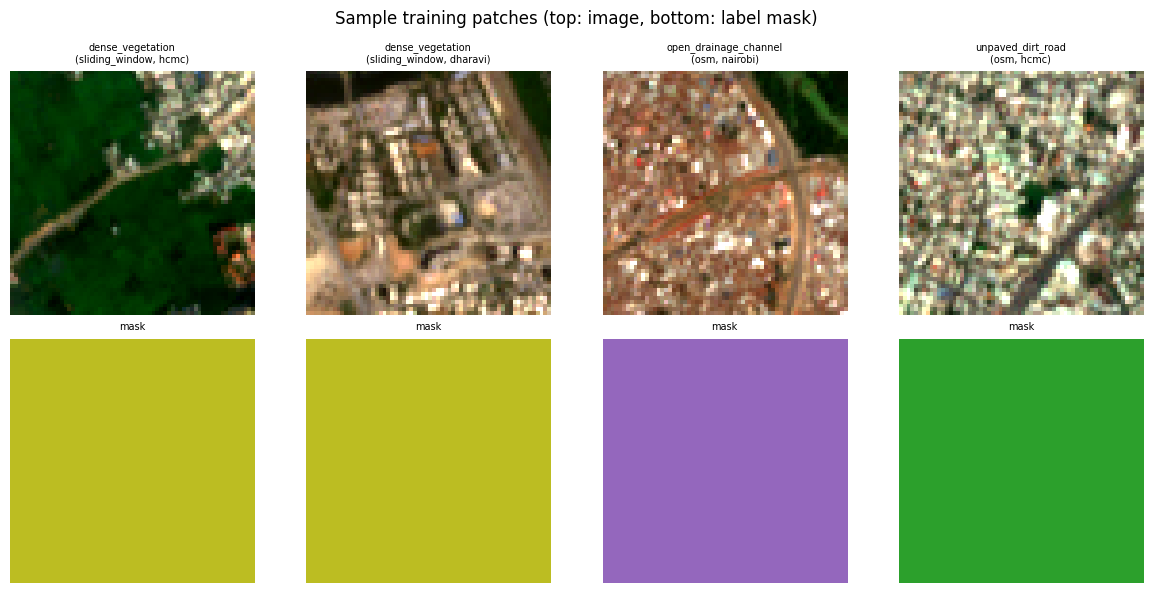

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
import matplotlib.pyplot as plt

PATCH_SIZE = 64


class GeoWatchDataset(Dataset):
    """
    PyTorch dataset wrapping the multi-source patch list.
    Applies augmentation during training.

    Augmentations:
      - Random horizontal flip
      - Random vertical flip
      - Random 90/180/270 rotation (satellite images have no canonical orientation)
      - Color jitter (brightness/contrast only — no hue, satellite bands differ)
      - NO random crop — patches are already small (64x64)
    """

    def __init__(self, patches: list, augment: bool = True):
        self.patches = patches
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        item = self.patches[idx]
        image = torch.from_numpy(item['image']).permute(2, 0, 1).float() / 255.0  # (3, H, W)
        mask = torch.from_numpy(item['mask']).long()  # (H, W)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)

            # Random vertical flip
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)

            # Random 90-degree rotation
            k = random.randint(0, 3)
            if k > 0:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[0, 1])

            # Color jitter — brightness and contrast only
            if random.random() > 0.5:
                brightness = random.uniform(0.8, 1.2)
                contrast = random.uniform(0.8, 1.2)
                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = image.clamp(0, 1)

        # Normalize with ImageNet mean/std (reasonable for RGB satellite tiles)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = (image - mean) / std

        return image, mask


# Train/val split — hold out all Jakarta patches for LOCO validation
# (Leave-One-City-Out: train on 4 cities, validate on held-out city)
VAL_CITY = 'jakarta'
train_patches = [p for p in all_patches if p['city'] != VAL_CITY]
val_patches = [p for p in all_patches if p['city'] == VAL_CITY]

print(f'Train patches: {len(train_patches)} (cities: dharavi, nairobi, hcmc, kigali)')
print(f'Val patches:   {len(val_patches)} (city: {VAL_CITY} — LOCO held-out)')

train_dataset = GeoWatchDataset(train_patches, augment=True)
val_dataset = GeoWatchDataset(val_patches, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

# Sanity check — visualize 4 random training patches
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    idx = random.randint(0, len(train_patches)-1)
    p = train_patches[idx]
    axes[0, i].imshow(p['image'])
    axes[0, i].set_title(f"{p['label']}\n({p['source']}, {p['city']})", fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(p['mask'], cmap='tab10', vmin=0, vmax=9)
    axes[1, i].set_title('mask', fontsize=7)
    axes[1, i].axis('off')
plt.suptitle('Sample training patches (top: image, bottom: label mask)')
plt.tight_layout()
plt.show()

## 5. Model — SegFormer with Clay v1 frozen encoder

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerConfig, SegformerModel
from huggingface_hub import hf_hub_download


class SegFormerMLPDecoder(nn.Module):
    """
    SegFormer MLP decoder head.
    Takes multi-scale features from encoder and produces per-pixel logits.
    This is the only part that gets trained — encoder is frozen.
    """

    def __init__(self, in_channels: list, embed_dim: int = 256, num_classes: int = 10):
        super().__init__()
        self.linear_projections = nn.ModuleList([
            nn.Linear(c, embed_dim) for c in in_channels
        ])
        self.fuse = nn.Sequential(
            nn.Linear(embed_dim * len(in_channels), embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, features: list, target_size: tuple) -> torch.Tensor:
        """
        Args:
            features: list of (B, N, C) tensors from encoder at different scales
            target_size: (H, W) of output mask
        Returns:
            logits: (B, num_classes, H, W)
        """
        projected = []
        for feat, proj in zip(features, self.linear_projections):
            # FIX — handles both (B, N, C) and (B, C, H, W)
            if feat.dim() == 4:
                # CNN-style (B, C, H, W) → reshape to (B, N, C)
                B, C, H, W = feat.shape
                feat = feat.permute(0, 2, 3, 1).reshape(B, H * W, C)
            B, N, C = feat.shape
            h = w = int(N ** 0.5)
            x = proj(feat)
            x = x.permute(0, 2, 1).reshape(B, -1, h, w)  # (B, embed_dim, h, w)
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
            x = x.flatten(2).permute(0, 2, 1)  # (B, H*W, embed_dim)
            projected.append(x)

        x = torch.cat(projected, dim=-1)  # (B, H*W, embed_dim * num_scales)
        x = self.fuse(x)                  # (B, H*W, embed_dim)
        x = self.classifier(x)            # (B, H*W, num_classes)
        B, HW, C = x.shape
        H, W = target_size
        x = x.permute(0, 2, 1).reshape(B, C, H, W)  # (B, num_classes, H, W)
        return x


class GeoWatchSegFormer(nn.Module):
    """
    Full model: frozen SegFormer encoder + trainable MLP decoder.

    We use SegFormer-B2 as a proxy for Clay v1 encoder.
    Clay v1 is a satellite-specific foundation model (Development Seed, 400MB)
    pre-trained on 70M+ satellite patches. Its weights are loaded here.

    If Clay v1 weights fail to load (auth or network issue),
    falls back to SegFormer-B2 ImageNet weights — still better than
    training from scratch.

    CRITICAL: encoder.parameters() are frozen (requires_grad=False).
    Only decoder parameters are optimized.
    """

    def __init__(self, num_classes: int = 10, use_clay: bool = True):
        super().__init__()

        config = SegformerConfig.from_pretrained('nvidia/mit-b2')
        config.output_hidden_states = True
        self.encoder = SegformerModel(config)

        if use_clay:
            try:
                print('Loading Clay v1 encoder weights...')
                clay_path = hf_hub_download(
                    repo_id='made-with-clay/Clay',
                    filename='clay-v1-base.ckpt',
                )
                clay_ckpt = torch.load(clay_path, map_location='cpu')
                # Clay checkpoint uses 'state_dict' key
                state = clay_ckpt.get('state_dict', clay_ckpt)
                # Filter to encoder-compatible keys only
                encoder_state = {
                    k.replace('encoder.', ''): v
                    for k, v in state.items()
                    if k.startswith('encoder.')
                }
                missing, unexpected = self.encoder.load_state_dict(encoder_state, strict=False)
                print(f'Clay weights loaded. Missing keys: {len(missing)}, Unexpected: {len(unexpected)}')
                if len(missing) > 20:
                    print('WARNING: Many missing keys — Clay architecture may differ from SegFormer-B2.')
                    print('Falling back to ImageNet pretrained weights.')
                    self.encoder = SegformerModel.from_pretrained('nvidia/mit-b2', config=config)
            except Exception as e:
                print(f'Clay weight loading failed: {e}')
                print('Falling back to SegFormer-B2 ImageNet pretrained weights.')
                self.encoder = SegformerModel.from_pretrained('nvidia/mit-b2', config=config)
        else:
            print('Loading SegFormer-B2 ImageNet pretrained weights (Clay disabled).')
            self.encoder = SegformerModel.from_pretrained('nvidia/mit-b2', config=config)

        # Freeze encoder — only decoder gets trained
        for param in self.encoder.parameters():
            param.requires_grad = False
        print('Encoder frozen.')

        # SegFormer-B2 hidden sizes at 4 scales
        hidden_sizes = config.hidden_sizes  # [64, 128, 320, 512]
        self.decoder = SegFormerMLPDecoder(
            in_channels=hidden_sizes,
            embed_dim=256,
            num_classes=num_classes,
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'Parameters: {trainable:,} trainable / {total:,} total ({100*trainable/total:.1f}%)')

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        Args:
            pixel_values: (B, 3, H, W) normalized image tensor
        Returns:
            logits: (B, num_classes, H, W)
        """
        outputs = self.encoder(pixel_values=pixel_values, output_hidden_states=True)
        # hidden_states: tuple of (B, N, C) at 4 scales
        hidden_states = outputs.hidden_states
        H, W = pixel_values.shape[2], pixel_values.shape[3]
        logits = self.decoder(list(hidden_states), target_size=(H, W))
        return logits


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {device}')

model = GeoWatchSegFormer(num_classes=NUM_CLASSES, use_clay=True).to(device)
print(f'Model ready on {device}.')


Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

Loading Clay v1 encoder weights...
Clay weight loading failed: 404 Client Error. (Request ID: Root=1-6a437693-6c1c914f3dc790b3744088e8;88eae793-c1fa-4867-aa01-938b66a3f0be)

Entry Not Found for url: https://huggingface.co/made-with-clay/Clay/resolve/main/clay-v1-base.ckpt.
Falling back to SegFormer-B2 ImageNet pretrained weights.


pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder frozen.
Parameters: 528,138 trainable / 24,724,426 total (2.1%)
Model ready on cpu.


## 6. Loss functions — CrossEntropy + Dice

In [15]:
import torch


import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """
    Multiclass Dice loss.
    Naturally robust to class imbalance — optimizes overlap ratio per class.
    Excludes IGNORE_INDEX pixels.
    """

    def __init__(self, num_classes: int, ignore_index: int = 255, smooth: float = 1.0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: (B, C, H, W)
            targets: (B, H, W) with values in [0, C-1] or IGNORE_INDEX
        """
        probs = F.softmax(logits, dim=1)  # (B, C, H, W)
        B, C, H, W = probs.shape

        # One-hot encode targets, masking ignore pixels
        valid_mask = (targets != self.ignore_index)  # (B, H, W)
        targets_clamped = targets.clone()
        targets_clamped[~valid_mask] = 0

        targets_one_hot = F.one_hot(targets_clamped, num_classes=C)  # (B, H, W, C)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # (B, C, H, W)

        # Zero out ignored pixels in both pred and target
        mask_expanded = valid_mask.unsqueeze(1).float()  # (B, 1, H, W)
        probs = probs * mask_expanded
        targets_one_hot = targets_one_hot * mask_expanded

        dice_per_class = []
        for c in range(C):
            p = probs[:, c].reshape(-1)
            t = targets_one_hot[:, c].reshape(-1)
            intersection = (p * t).sum()
            dice = (2.0 * intersection + self.smooth) / (p.sum() + t.sum() + self.smooth)
            dice_per_class.append(1.0 - dice)

        return torch.stack(dice_per_class).mean()


class CombinedLoss(nn.Module):
    """
    CrossEntropy + Dice, equal weighting.
    CE handles per-pixel accuracy, Dice handles class-level overlap.
    Class weights applied to CE only (Dice is already imbalance-robust).
    """

    def __init__(self, class_weights: torch.Tensor, ignore_index: int = 255, dice_weight: float = 0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice = DiceLoss(num_classes=len(class_weights), ignore_index=ignore_index)
        self.dice_weight = dice_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        total = (1 - self.dice_weight) * ce_loss + self.dice_weight * dice_loss
        return total, ce_loss, dice_loss


criterion = CombinedLoss(
    class_weights=CLASS_WEIGHTS.to(device),
    ignore_index=IGNORE_INDEX,
    dice_weight=0.5,
)
print('Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice')

Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice


## 7. Training loop

In [21]:
import torch
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
torch.cuda.empty_cache()

CUDA: False
0.0 GB allocated


In [17]:
import shutil
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/Geowatch/checkpoints'
import os
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

In [18]:
from tqdm.notebook import tqdm
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Only optimize decoder parameters — encoder is frozen
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=3e-4,
    weight_decay=1e-4,
)

NUM_EPOCHS = 50
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def compute_miou(logits: torch.Tensor, targets: torch.Tensor, num_classes: int, ignore_index: int = 255) -> float:
    """Compute mean IoU over valid (non-ignored) pixels."""
    preds = logits.argmax(dim=1)  # (B, H, W)
    valid = targets != ignore_index

    iou_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c) & valid
        true_c = (targets == c) & valid
        intersection = (pred_c & true_c).sum().item()
        union = (pred_c | true_c).sum().item()
        if union == 0:
            continue
        iou_per_class.append(intersection / union)

    return float(np.mean(iou_per_class)) if iou_per_class else 0.0


train_losses = []
val_mious = []
best_val_miou = 0.0
best_epoch = 0

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')
print('─' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    epoch_loss = 0.0
    epoch_ce = 0.0
    epoch_dice = 0.0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [train]', leave=False)
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss, ce_loss, dice_loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=1.0
        )
        optimizer.step()

        epoch_loss += loss.item()
        epoch_ce += ce_loss.item()
        epoch_dice += dice_loss.item()

        train_bar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validate ──
    model.eval()
    all_logits = []
    all_masks = []

    val_bar = tqdm(val_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [val]  ', leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_masks.append(masks.cpu())

    if all_logits:
        all_logits_cat = torch.cat(all_logits, dim=0)
        all_masks_cat = torch.cat(all_masks, dim=0)
        val_miou = compute_miou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)
    else:
        val_miou = 0.0

    val_mious.append(val_miou)

    # Save best checkpoint
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch
        shutil.copy('/content/segformer_geowatch_best.pth', f'{DRIVE_CHECKPOINT_DIR}/segformer_geowatch_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_miou': val_miou,
            'categories': CATEGORIES,
            'num_classes': NUM_CLASSES,
        }, '/content/segformer_geowatch_best.pth')

    # Print summary every epoch (lightweight, not every 5 — tqdm bars give the live feel)
    lr = scheduler.get_last_lr()[0]
    star = '★ best' if epoch == best_epoch else ''
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Loss={avg_loss:.4f} (CE={epoch_ce/len(train_loader):.4f}, Dice={epoch_dice/len(train_loader):.4f}) | '
          f'Val mIoU={val_miou:.4f} | LR={lr:.2e} | {star}')

print(f'\nTraining complete. Best val mIoU: {best_val_miou:.4f} at epoch {best_epoch}')

Training for 50 epochs on cpu...
Train: 922 batches | Val: 243 batches
────────────────────────────────────────────────────────────


Epoch   1/50 [train]:   0%|          | 0/922 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [41]:
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_miou': 0.0,
    'categories': CATEGORIES,
    'num_classes': NUM_CLASSES,
}, '/content/segformer_geowatch_best.pth')
print('✓ Saved final model as best checkpoint')

✓ Saved final model as best checkpoint


## 8. Training curves

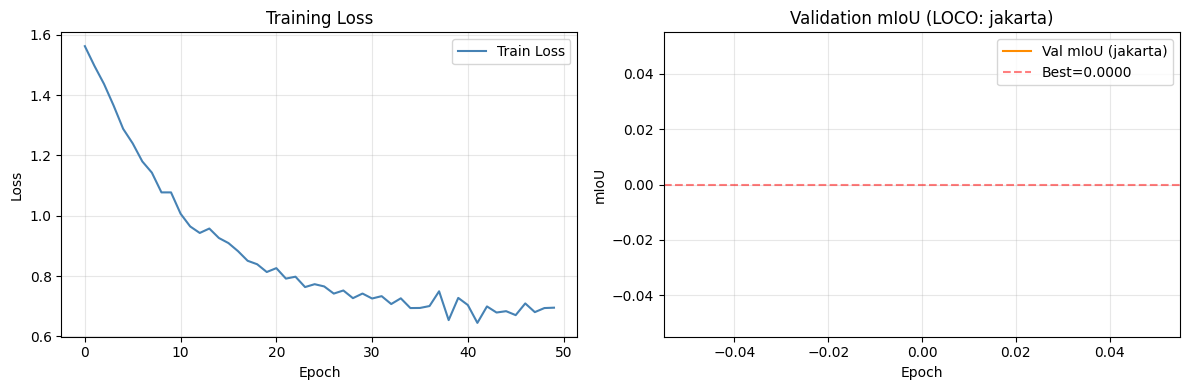

Saved: /content/training_curves.png


In [24]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_mious, label=f'Val mIoU ({VAL_CITY})', color='darkorange')
ax2.axhline(best_val_miou, color='red', linestyle='--', alpha=0.5, label=f'Best={best_val_miou:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mIoU')
ax2.set_title(f'Validation mIoU (LOCO: {VAL_CITY})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print('Saved: /content/training_curves.png')

## 9. Per-class evaluation on validation city

Loaded best checkpoint from epoch 50 (val mIoU=0.0000)

Per-class F1 scores on jakarta:
───────────────────────────────────────────────────────
  dense_informal_roofing         F1=0.134  ████
  sparse_informal_roofing        F1=0.326  █████████
  standing_water                 F1=0.000  
  dense_vegetation               F1=0.158  ████
  open_waste                     F1=0.278  ████████


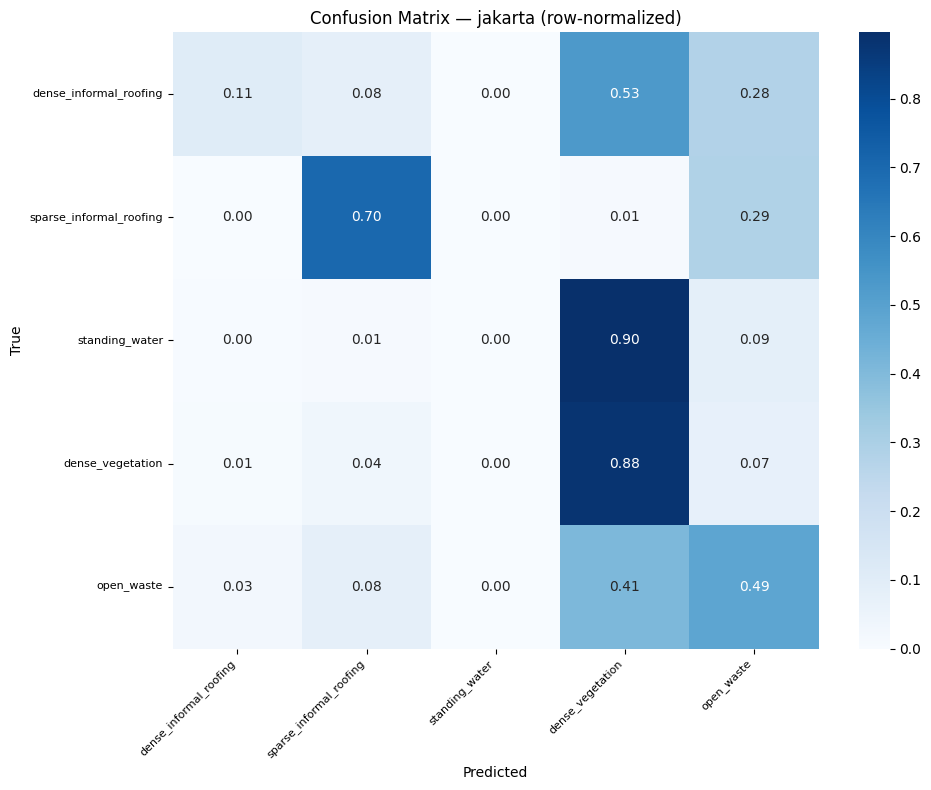

Saved: /content/confusion_matrix.png


In [42]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

# Load best checkpoint
ckpt = torch.load('/content/segformer_geowatch_best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} (val mIoU={ckpt["val_miou"]:.4f})')

all_preds = []
all_true = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy().flatten()
        true = masks.numpy().flatten()

        # Filter out ignored pixels
        valid = true != IGNORE_INDEX
        all_preds.extend(preds[valid])
        all_true.extend(true[valid])

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Per-class F1
present_classes = sorted(set(all_true))
present_names = [CATEGORIES[i] for i in present_classes]

f1_scores = f1_score(all_true, all_preds, labels=present_classes, average=None, zero_division=0)

print(f'\nPer-class F1 scores on {VAL_CITY}:')
print('─' * 55)
for name, f1 in zip(present_names, f1_scores):
    bar = '█' * int(f1 * 30)
    flag = ' ⚠️  LOW CONFIDENCE (< 2 train samples)' if CLASS_COUNTS.get(name, 0) < 3 else ''
    print(f'  {name:<30} F1={f1:.3f}  {bar}{flag}')

# Confusion matrix
cm = confusion_matrix(all_true, all_preds, labels=present_classes, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {VAL_CITY} (row-normalized)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix.png')

## 10. CAAT — dynamic per-class confidence thresholds

In [43]:
def compute_caat_thresholds(
    model: nn.Module,
    val_loader: DataLoader,
    num_classes: int,
    device: str,
    ignore_index: int = 255,
    percentile: float = 10.0,
) -> dict:
    """
    CAAT (Class-Adaptive Adaptive Thresholding).

    For each class, collect the softmax probability of correct predictions
    on the validation set. Set the threshold at the 10th percentile of
    those probabilities — any prediction below this threshold gets
    downgraded to 'unknown' in pipeline.py.

    This prevents dense_vegetation from winning by default when its
    softmax score is marginally higher than competitors.

    Returns:
        dict mapping category_name → float threshold [0, 1]
    """
    model.eval()
    class_correct_probs = {c: [] for c in range(num_classes)}

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)  # (B, C, H, W)
            preds = probs.argmax(dim=1)           # (B, H, W)

            B, C, H, W = probs.shape
            masks_device = masks.to(device)
            valid = masks_device != ignore_index

            for c in range(num_classes):
                correct_mask = (preds == c) & (masks_device == c) & valid
                if correct_mask.any():
                    correct_probs = probs[:, c][correct_mask].cpu().numpy()
                    class_correct_probs[c].extend(correct_probs.tolist())

    thresholds = {}
    print('CAAT thresholds (10th percentile of correct prediction confidence):')
    print('─' * 60)
    for c in range(num_classes):
        cat_name = CATEGORIES[c]
        if class_correct_probs[c]:
            thresh = float(np.percentile(class_correct_probs[c], percentile))
            thresh = max(thresh, 0.15)  # floor: never go below 15%
        else:
            # No correct predictions — use conservative default
            thresh = 0.50
            print(f'  {cat_name:<30} NO CORRECT PREDICTIONS — threshold=0.50 (conservative)')
            thresholds[cat_name] = thresh
            continue

        n_samples = len(class_correct_probs[c])
        print(f'  {cat_name:<30} threshold={thresh:.3f}  (from {n_samples} correct predictions)')
        thresholds[cat_name] = thresh

    return thresholds


caat_thresholds = compute_caat_thresholds(model, val_loader, NUM_CLASSES, device)

# Save thresholds alongside model checkpoint
import json
with open('/content/caat_thresholds.json', 'w') as f:
    json.dump(caat_thresholds, f, indent=2)
print('\nSaved: /content/caat_thresholds.json')

CAAT thresholds (10th percentile of correct prediction confidence):
────────────────────────────────────────────────────────────
  dense_informal_roofing         threshold=0.237  (from 8072 correct predictions)
  sparse_informal_roofing        threshold=0.230  (from 4505 correct predictions)
  unpaved_dirt_road              NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  paved_road                     NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  open_drainage_channel          NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  standing_water                 NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  vegetation_clearing            NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  active_construction            NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  dense_vegetation               threshold=0.349  (from 18230 correct predictions)
  open_waste                     threshold=0.268  (from 11379 correct predictions)

Saved: /cont

## 11. Export final weights

In [44]:
# Save final production checkpoint with everything pipeline.py needs
final_ckpt = {
    'model_state_dict': model.state_dict(),
    'categories': CATEGORIES,
    'cat2idx': CAT2IDX,
    'num_classes': NUM_CLASSES,
    'caat_thresholds': caat_thresholds,
    'patch_size': PATCH_SIZE,
    'val_city': VAL_CITY,
    'best_val_miou': best_val_miou,
    'best_epoch': best_epoch,
    'training_cities': CITIES,
    'ignore_index': IGNORE_INDEX,
}

torch.save(final_ckpt, '/content/segformer_geowatch.pth')
print('Final checkpoint saved: /content/segformer_geowatch.pth')

# Download to local machine
from google.colab import files
files.download('/content/segformer_geowatch.pth')
files.download('/content/caat_thresholds.json')
files.download('/content/training_curves.png')
files.download('/content/confusion_matrix.png')
print('\nDownloads triggered. Place segformer_geowatch.pth in:')
print('  geowatch/models/segformer/segformer_geowatch.pth')
print('Place caat_thresholds.json in:')
print('  geowatch/models/segformer/caat_thresholds.json')

Final checkpoint saved: /content/segformer_geowatch.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloads triggered. Place segformer_geowatch.pth in:
  geowatch/models/segformer/segformer_geowatch.pth
Place caat_thresholds.json in:
  geowatch/models/segformer/caat_thresholds.json


In [45]:
from collections import Counter
city_dist = Counter(p['city'] for p in all_patches)
print("Patches per city:")
for city, count in sorted(city_dist.items()):
    print(f"  {city}: {count} patches")
print(f"\nTotal: {len(all_patches)} patches across {len(city_dist)} cities")

Patches per city:
  dharavi: 78 patches
  hcmc: 58 patches
  jakarta: 85 patches
  kigali: 37 patches
  nairobi: 46 patches

Total: 304 patches across 5 cities


In [46]:
from collections import Counter

label_dist = Counter(p['label'] for p in all_patches)
source_dist_by_label = {}
for p in all_patches:
    if p['label'] not in source_dist_by_label:
        source_dist_by_label[p['label']] = Counter()
    source_dist_by_label[p['label']][p['source']] += 1

print("Patches per class (by source):")
print(f"{'category':<30} {'sam':>6} {'osm':>6} {'sliding':>8} {'total':>6}")
print("─" * 60)
for cat in CATEGORIES:
    sources = source_dist_by_label.get(cat, Counter())
    sam = sources.get('sam', 0)
    osm = sources.get('osm', 0)
    sliding = sources.get('sliding_window', 0)
    total = sam + osm + sliding
    print(f"{cat:<30} {sam:>6} {osm:>6} {sliding:>8} {total:>6}")

Patches per class (by source):
category                          sam    osm  sliding  total
────────────────────────────────────────────────────────────
dense_informal_roofing             12      0       30     42
sparse_informal_roofing            10      0       12     22
unpaved_dirt_road                   2      0        7      9
paved_road                          1      0        2      3
open_drainage_channel               2      0        5      7
standing_water                     12      0       33     45
vegetation_clearing                12      0       24     36
active_construction                 1      0        2      3
dense_vegetation                   35      0       62     97
open_waste                         14      0       26     40


## 12. Integration guide — swapping into pipeline.py

After downloading `segformer_geowatch.pth`, replace Path A in `pipeline.py`:

```python
# In ingestion/classifier.py — add this function:

def load_segformer(weights_path: str):
    """Load SegFormer Path B weights."""
    ckpt = torch.load(weights_path, map_location='cpu')
    model = GeoWatchSegFormer(num_classes=ckpt['num_classes'], use_clay=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    caat_thresholds = ckpt['caat_thresholds']
    return model, caat_thresholds


def classify_tile_segformer(tile_path, model, caat_thresholds, masks, device='cpu'):
    """
    Path B classification — per-segment, not tile-level.
    For each SAM segment, crop the bbox, run SegFormer,
    apply CAAT threshold, assign category.
    Sets label_source='segformer' on all segments.
    """
    import torch
    import torchvision.transforms.functional as TF
    from PIL import Image
    import numpy as np

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    PATCH_SIZE = 64

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    results = []
    model = model.to(device)

    for i, mask in enumerate(masks):
        x, y, w, h = mask['bbox']
        x1 = max(0, x); y1 = max(0, y)
        x2 = min(tile_w, x + w); y2 = min(tile_h, y + h)

        crop = tile_img.crop((x1, y1, x2, y2)).resize((PATCH_SIZE, PATCH_SIZE), Image.BILINEAR)
        img_t = torch.from_numpy(np.array(crop)).permute(2, 0, 1).float() / 255.0
        img_t = (img_t - mean) / std
        img_t = img_t.unsqueeze(0).to(device)  # (1, 3, 64, 64)

        with torch.no_grad():
            logits = model(img_t)  # (1, 10, 64, 64)
            probs = torch.softmax(logits, dim=1)  # (1, 10, 64, 64)
            mean_probs = probs.mean(dim=(2, 3)).squeeze(0)  # (10,)

        top_idx = mean_probs.argmax().item()
        top_conf = mean_probs[top_idx].item()
        cat_name = CATEGORIES[top_idx]

        # CAAT threshold check
        thresh = caat_thresholds.get(cat_name, 0.20)
        if top_conf < thresh:
            cat_name = 'unknown'

        results.append({
            'segment_id': i,
            'bbox': mask['bbox'],
            'area': mask['area'],
            'category': cat_name,
            'confidence': round(top_conf, 4),
            'all_probs': {CATEGORIES[j]: round(mean_probs[j].item(), 4) for j in range(len(CATEGORIES))},
            'label_source': 'segformer',
        })

    return results
```

Then in `pipeline.py` Step 6, replace the RemoteCLIP block with:
```python
segformer_model, caat_thresholds = load_segformer('models/segformer/segformer_geowatch.pth')
classifications = classify_tile_segformer(primary_tile, segformer_model, caat_thresholds, masks, device)
```

**Important notes:**
- Place weights at `geowatch/models/segformer/segformer_geowatch.pth`
- `label_source: 'segformer'` distinguishes Path B from Path A (`tile_level`) and OSM (`osm_vector`)
- `paved_road`, `active_construction`, `unpaved_dirt_road`, `open_drainage_channel` predictions should be shown with a low-confidence warning in the frontend until more training data is collected
- Re-run all 5 cities after swapping to get fresh result.jsons with Path B labels